# Data Exploration for Multimodal Drone Detection
Ethan Mauger

This notebook documents fully exploring all datasets used to train the offline_ml models. This notebook explores modality imbalances, dataset size, label accuracy and completeness, image/dataset characteristics, and bounding box location and size distributions. Additional information about specifics of each dataset is presented below.

## Basic Statistics

The code below shows us the total number of images per dataset, and the breakdown between training, testing, and validation splits.

Notes:
- Modailities are fairly balanced between all datasets, with the thermal modality having a slightly larger pool of images in total compared to the visual modality (slightly larger pool is coming from the Halmstad data).
- Splits are fairly balanced among all of the datasets as well, keeping about a 70% training split, 15% validation split, and 15% test split for each dataset and each modality.
- While the Zenodo datasets lack negative samples (samples with missing labels) and the Anti_UAV sets lack other objects in those negative samples (just plain images with no drones), the Halmstad dataset has a majority of negative samples with other objects (birds, helicopters, planes). These will be really useful when combining datasets together to ensure all sets are trained on data with negative samples.
- zenodo_thermal_no_augmentation images with missing labels (drone was present, label wasn't) were removed from the dataset.

*Future Work:*
- *Size of datasets might need to be balanced in the future so the model can train on all datasets equally.*

In [15]:
import os

#ADD ADDITIONAL DATASETS HERE AS MORE ARE ADDED
dataset_names = [
    "zenodo_visual_no_augmentation",
    "zenodo_thermal_no_augmentation",
    "anti_uav_visual_no_augmentation",
    "anti_uav_thermal_no_augmentation",
    "halmstad_visual_no_augmentation",
    "halmstad_thermal_no_augmentation"
]
test_sets = ["train", "test", "valid"]

for dataset in dataset_names:
    print(f"Dataset: {dataset}")
    total = 0

    for subset in test_sets:
        base_dir = os.path.join("..", "datasets", dataset, subset)
        images_dir = os.path.join(base_dir, "images")
        print(f"{subset}: {len(os.listdir(images_dir))} images.")
        total += len(os.listdir(images_dir))

    print(f"Total Images: {total}")
    print("--------------------------")

Dataset: zenodo_visual_no_augmentation
train: 1502 images.
test: 214 images.
valid: 429 images.
Total Images: 2145
--------------------------
Dataset: zenodo_thermal_no_augmentation
train: 1236 images.
test: 172 images.
valid: 352 images.
Total Images: 1760
--------------------------
Dataset: anti_uav_visual_no_augmentation
train: 14972 images.
test: 8547 images.
valid: 6208 images.
Total Images: 29727
--------------------------
Dataset: anti_uav_thermal_no_augmentation
train: 14972 images.
test: 8547 images.
valid: 6208 images.
Total Images: 29727
--------------------------
Dataset: halmstad_visual_no_augmentation
train: 6275 images.
test: 1295 images.
valid: 1358 images.
Total Images: 8928
--------------------------
Dataset: halmstad_thermal_no_augmentation
train: 8082 images.
test: 1736 images.
valid: 1752 images.
Total Images: 11570
--------------------------


In [16]:
for dataset in dataset_names:
    print(f"Dataset: {dataset}")
    total = 0
    total_empty = 0

    for subset in test_sets:
        base_dir = os.path.join("..", "datasets", dataset, subset)
        labels_dir = os.path.join(base_dir, "labels")
        label_files = os.listdir(labels_dir)

        # Check to see which labels are empty.
        subset_empty = 0

        for label_file in label_files:
            file_path = os.path.join(labels_dir, label_file)

            with open(file_path) as f:
                content = f.read().strip()

            if not content:
                subset_empty += 1

        print(f"{subset}: {len(os.listdir(labels_dir))} labels.")
        print(f"{subset}: {subset_empty} empty labels.")
        print("------------------------")

        total_empty += subset_empty
        total += len(os.listdir(labels_dir))

    print(f"Total Labels: {total}")
    print(f"Total Empty Labels: {total_empty}")
    print("------------------------")
    print("------------------------")

Dataset: zenodo_visual_no_augmentation
train: 1502 labels.
train: 0 empty labels.
------------------------
test: 214 labels.
test: 0 empty labels.
------------------------
valid: 429 labels.
valid: 0 empty labels.
------------------------
Total Labels: 2145
Total Empty Labels: 0
------------------------
------------------------
Dataset: zenodo_thermal_no_augmentation
train: 1236 labels.
train: 0 empty labels.
------------------------
test: 172 labels.
test: 0 empty labels.
------------------------
valid: 352 labels.
valid: 0 empty labels.
------------------------
Total Labels: 1760
Total Empty Labels: 0
------------------------
------------------------
Dataset: anti_uav_visual_no_augmentation
train: 14972 labels.
train: 736 empty labels.
------------------------
test: 8547 labels.
test: 559 empty labels.
------------------------
valid: 6208 labels.
valid: 372 empty labels.
------------------------
Total Labels: 29727
Total Empty Labels: 1667
------------------------
-------------------

## Image Analysis

Notes:
- Images have various sizes but are all stored in the .jpg format
- Zenodo pictures are clear and in the daytime, but have varying weather varieties such as clear skies, cloudy, and overcast. The images depict varying backgrounds of the sky and other buildings/structures commonly found around a suburban/school/farm area. There is also plenty of foiliage in the images as well, and the images appear to be shared between the different datasets, just taken with a different modality. These images provide a large range of different backgrounds and photos to allow training to occur, and will be super helpful in training a model to discover drones in similar areas.
- Anti-UAV images feature various backgrounds as well, but these images are taken much higher up in the sky, backgrounds include clouds, buildings/skyscrapers, plain sky, and more, and feature multiple different times of the day. There is a lack of foiliage in these sets due to the altitude, but the drones are much further away, allowing our model to train to detect drones from a further distance giving users more time given the information presented.
- Halmstad images are more similar to each other, having mostly clear skies in the bacground with some overcast or cloud coverage sometimes. Most images were collected during the day, and usually have some sort of noise in the bottom of the screen, but this noise usually doesn't overlap with the drone like it does in the other sets. The main draw of the halmstad data is the negative samples it provides, whereas sets like Anti_UAV or Zenodo can carry the main weight with the actual noise distribution that would mimic the Secret Service use case the closest.
- Labels on all images with drones are clear and follow a specific YOLO format. There are no labels on images without drones and no missing labels on images that include drones and should be labeled.

*Future Work:*
- *Create additional augmentations for sets to improve model accuracy*
- *Erase/blur crosshairs on Anti_UAV visual data for consistency with other sets*

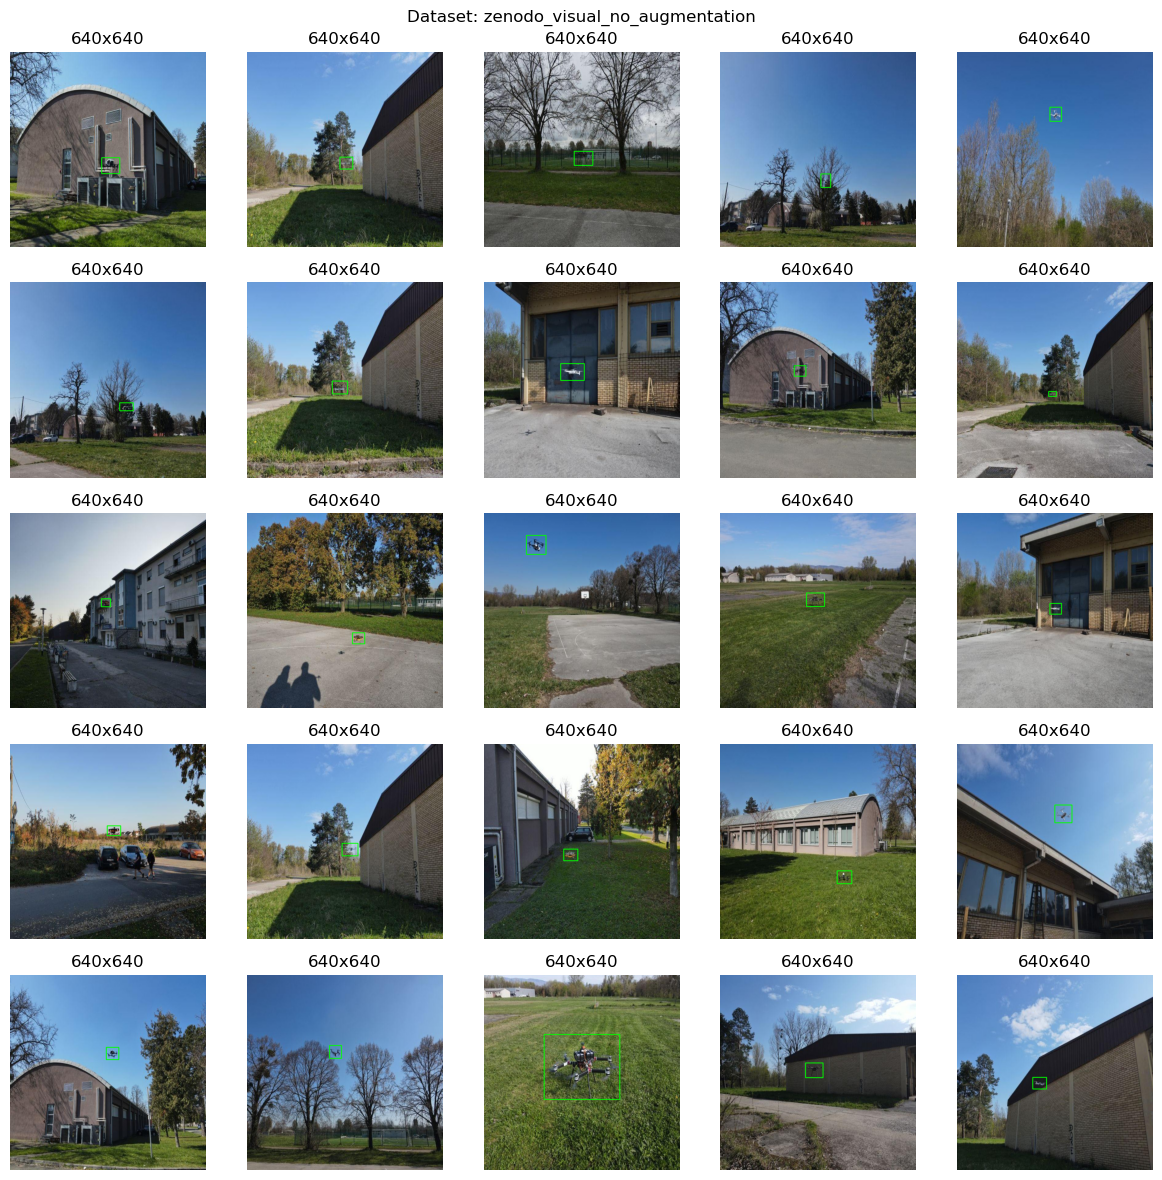

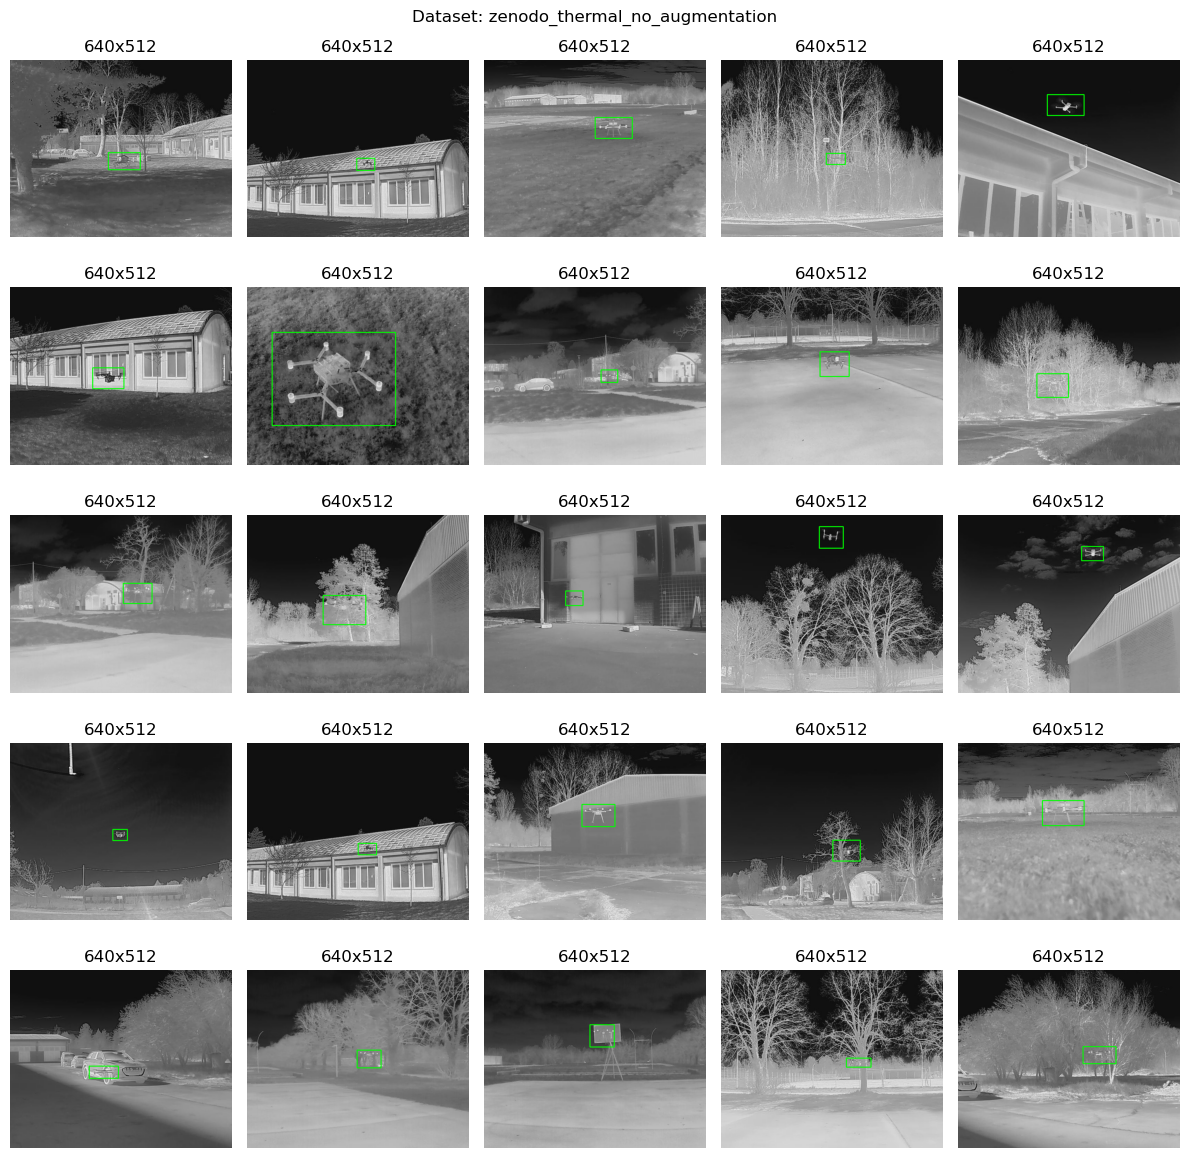

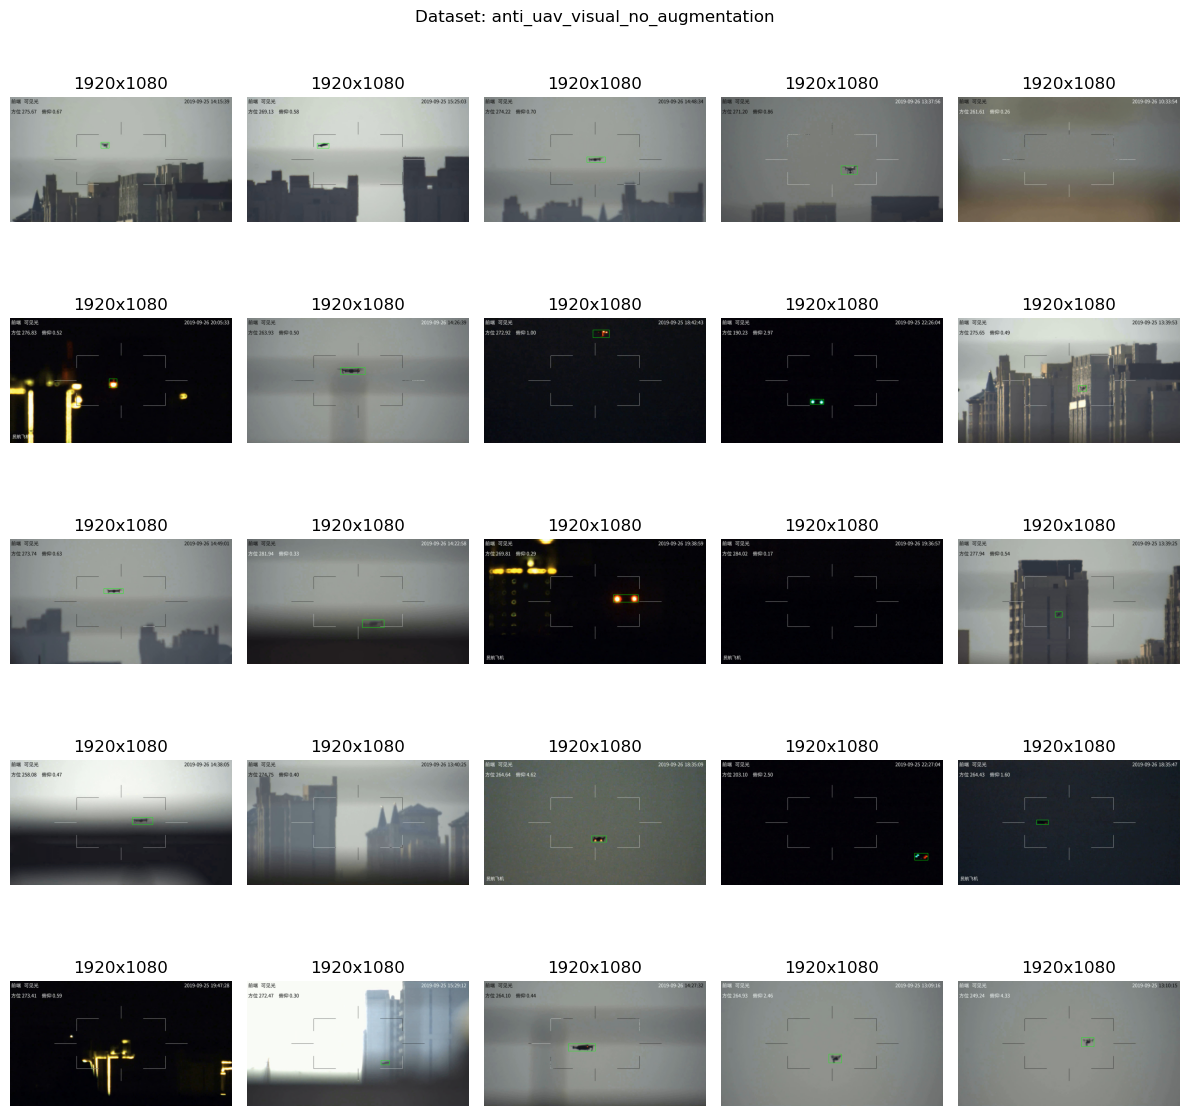

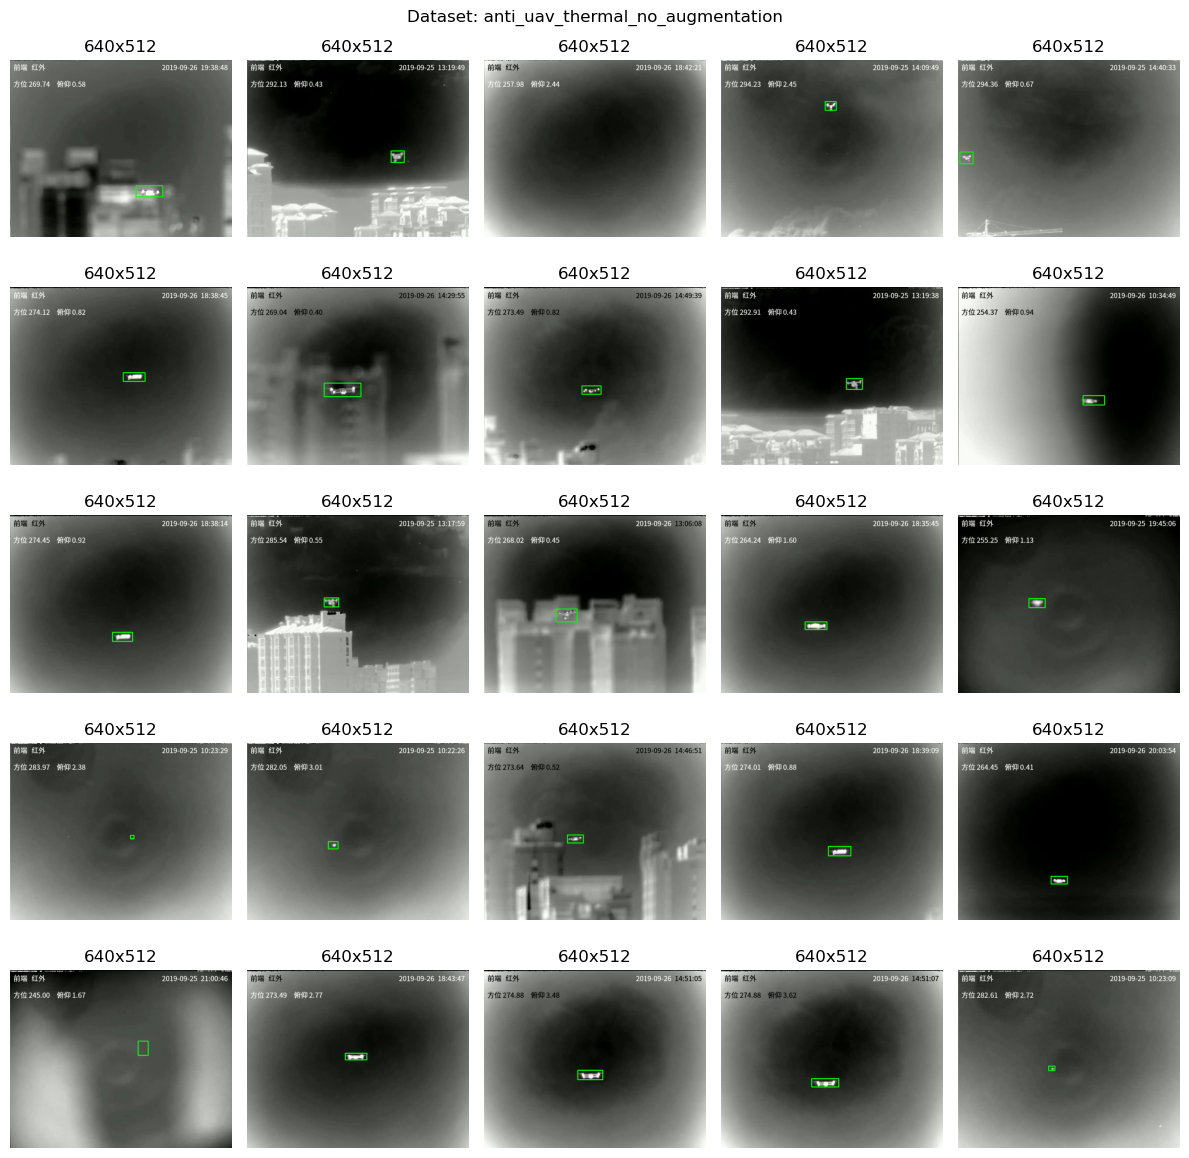

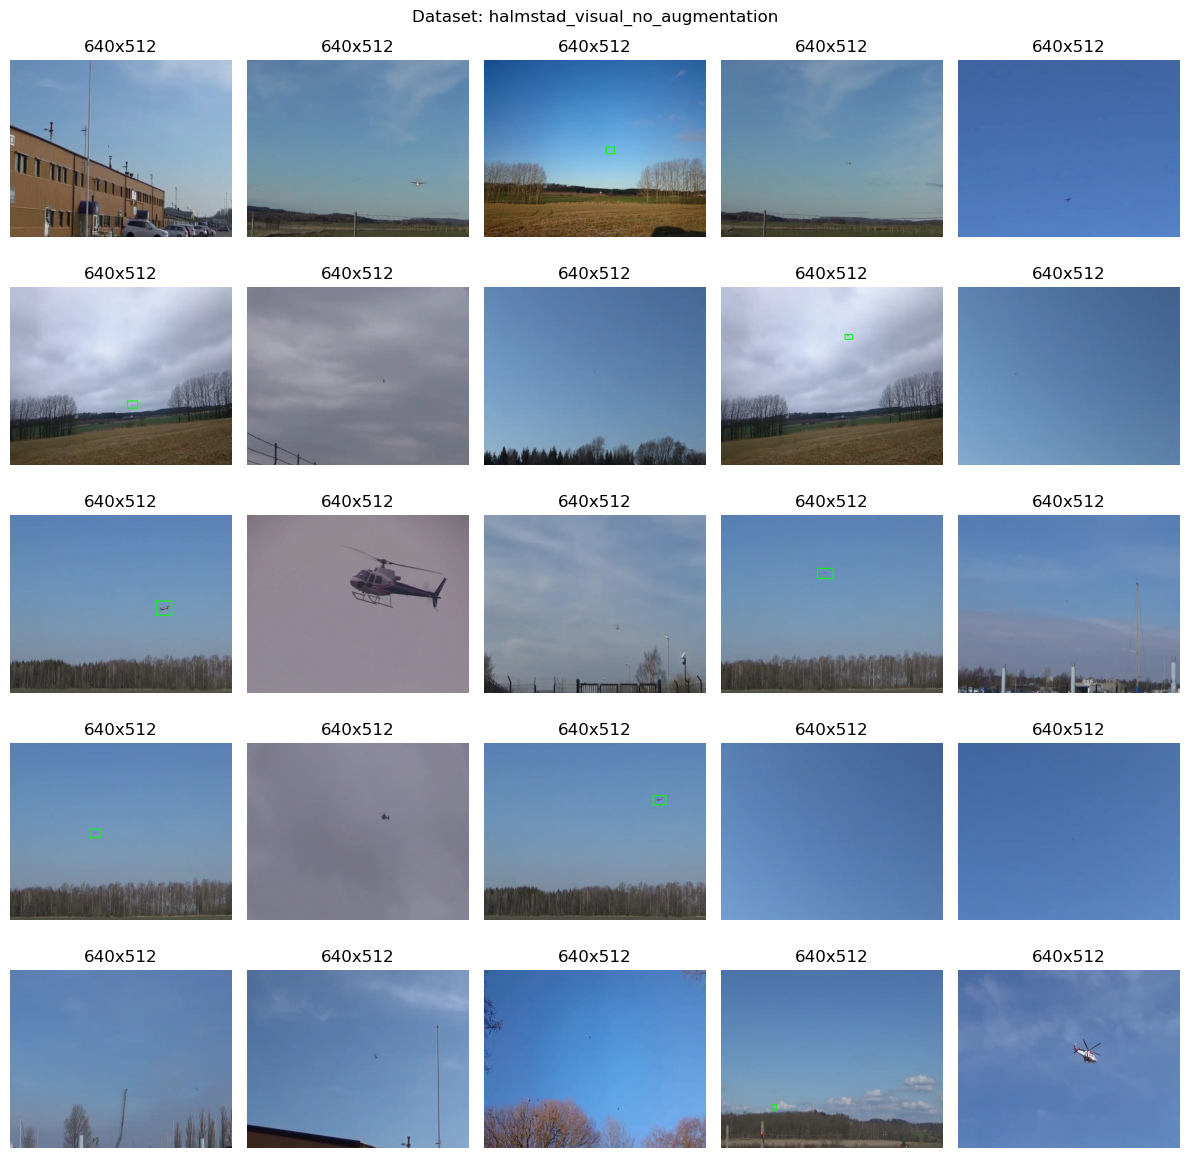

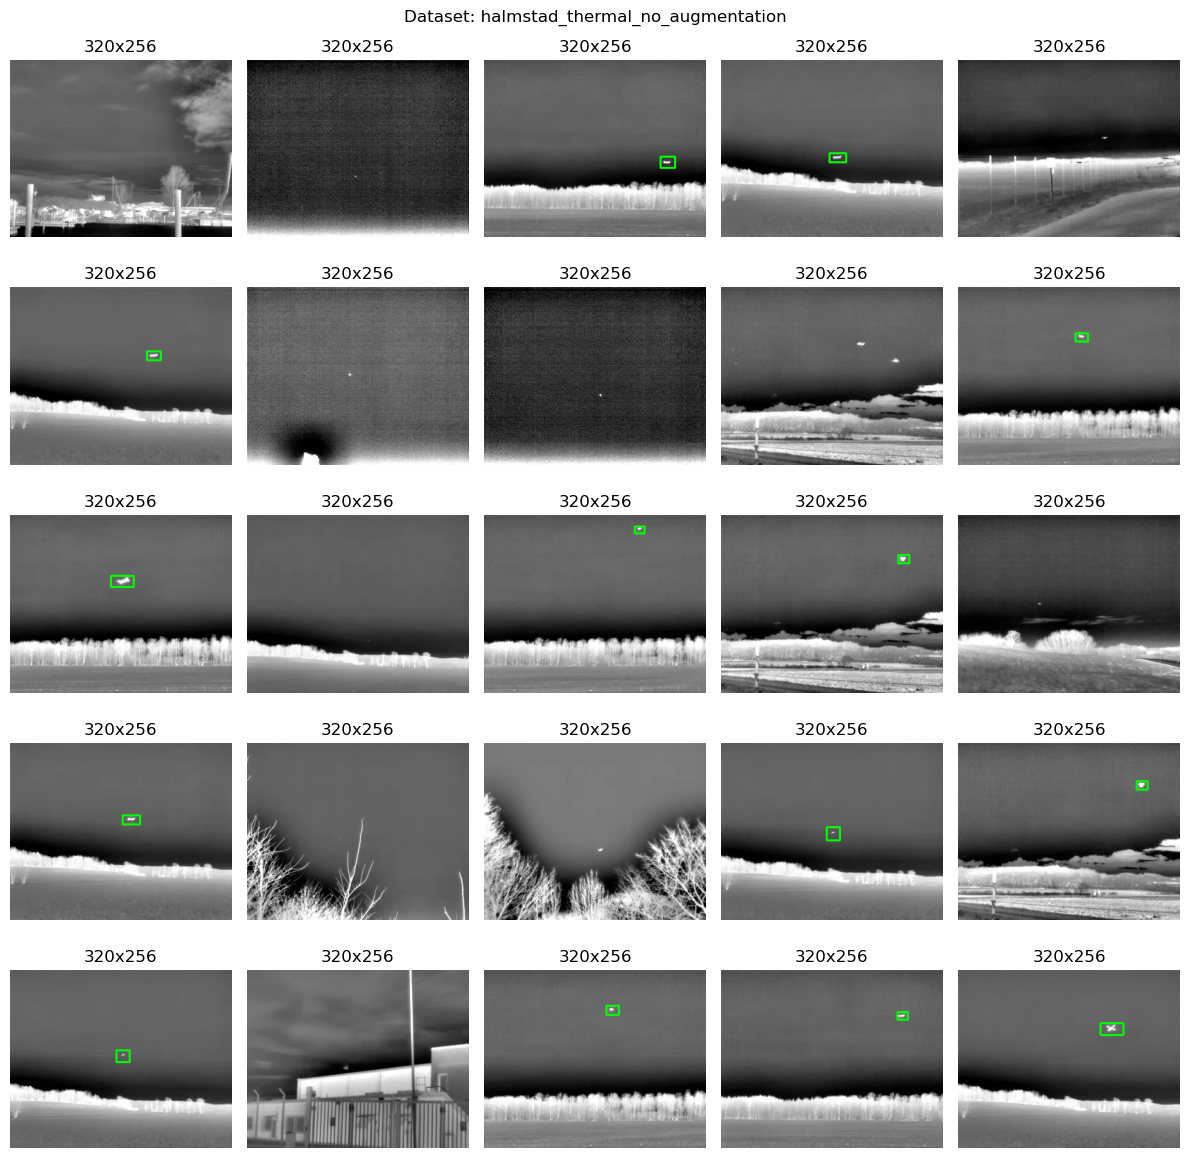

In [17]:
import random

import cv2
import matplotlib.pyplot as plt
import numpy

# Images to show per dataset.
# Input should be a perfect square and should be less than the number of images in the dataset.
images_per_dataset = 25
grid_size = int(numpy.sqrt(images_per_dataset))

for dataset in dataset_names:
    base_dir = os.path.join("..", "datasets", dataset, "train", "images")
    labels_dir = os.path.join("..", "datasets", dataset, "train", "labels")
    image_files = os.listdir(base_dir)

    # Randomly select images.
    selected_images = random.sample(image_files, images_per_dataset)

    # Create plot structure.
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    axes = axes.flatten()
    fig.suptitle(f"Dataset: {dataset}")

    # Load images.
    for i, image_file in enumerate(selected_images):
        img_path = os.path.join(base_dir, image_file)
        img = cv2.imread(img_path)

        # Load labels for bounding boxes for each image.
        label_path = os.path.join(labels_dir, image_file.replace(".jpg", ".txt"))

        with open(label_path) as f:
            content = f.read().split()

            # If the file is labeled, produce a bounding box given the normalized center
            # of the box and the box width and height.
            if content:
                x = float(content[1])
                y = float(content[2])
                w = float(content[3])
                h = float(content[4])

                # Convert to pixel coordinates and display to the screen.
                x1 = int((x - w / 2) * img.shape[1])
                y1 = int((y - h / 2) * img.shape[0])
                x2 = int((x + w / 2) * img.shape[1])
                y2 = int((y + h / 2) * img.shape[0])
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image and size of image.
        axes[i].imshow(img_rgb)
        axes[i].axis("off")
        axes[i].set_title(f"{img.shape[1]}x{img.shape[0]}")

    plt.tight_layout()
    plt.show()

## Bounding Box Analysis

Notes
- Bounding boxes are primarily found in the center of the image in all datasets, but while the zenodo datasets cover more vertical variation the Anti-UAV datasets cover more horizontal variation. In addition, while the Halmstad dataset doesn't have a lot of drone labels, the bounding boxes are much more scattered around within the size of the image which is very nice for variation.
- The location of the bounding box is dependent on the size of the image. For example, since the Halmstad thermal images have a size of 320 x 256, which is half of the size of the Halmstad visual images, all of the bounding boxes appear in the bottom right of the grid. This is how YOLO will interpret the location of the bounding boxes when all of the images are normalized to the consistent YOLO image format. 
- Zenodo datasets featured primarily small bounding boxes but some outliers showed large bounding boxes in the data, which is good for data variety. However, the Anti-UAV and Halmstad data feature many images with much smaller bounding boxes in comparison, and will be helpful for trying to detect drones from greater distances away.

*Future Work*
- *Expand location of bounding boxes with image augmentation*

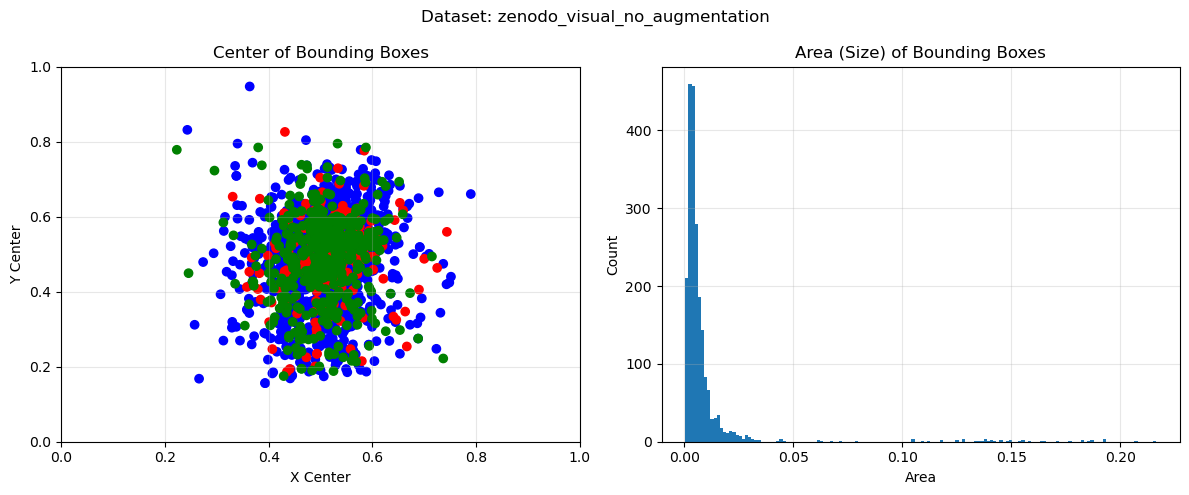

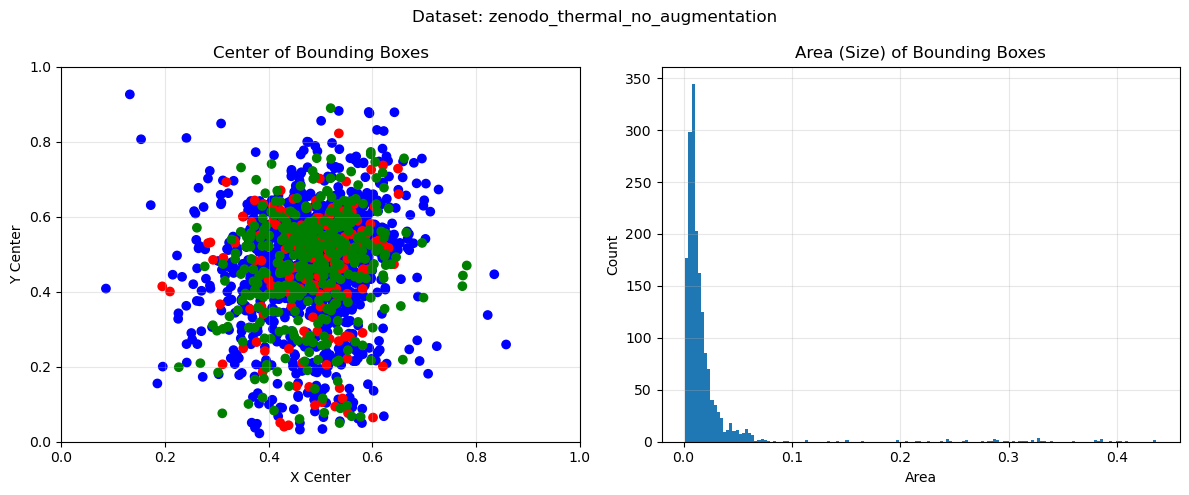

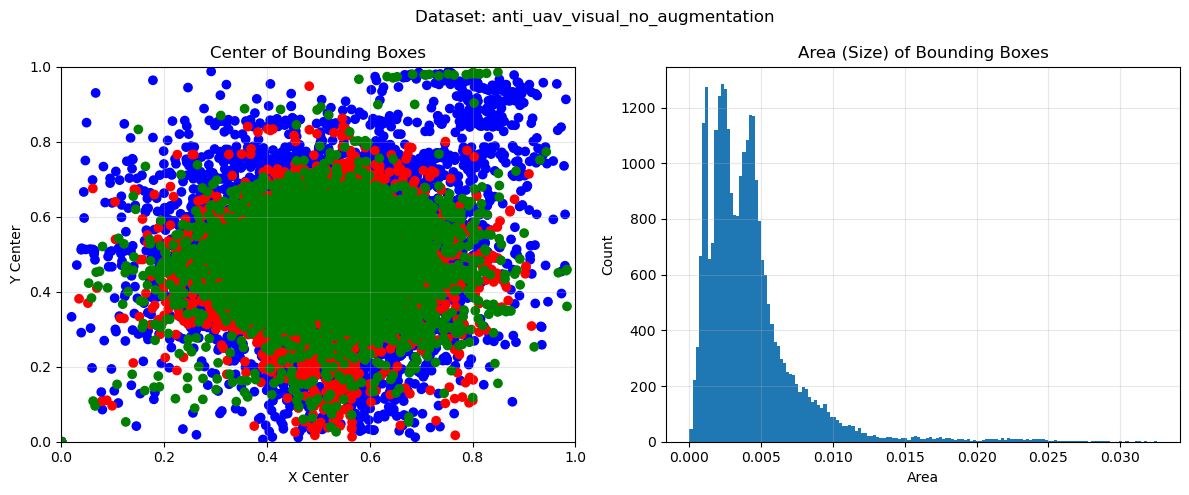

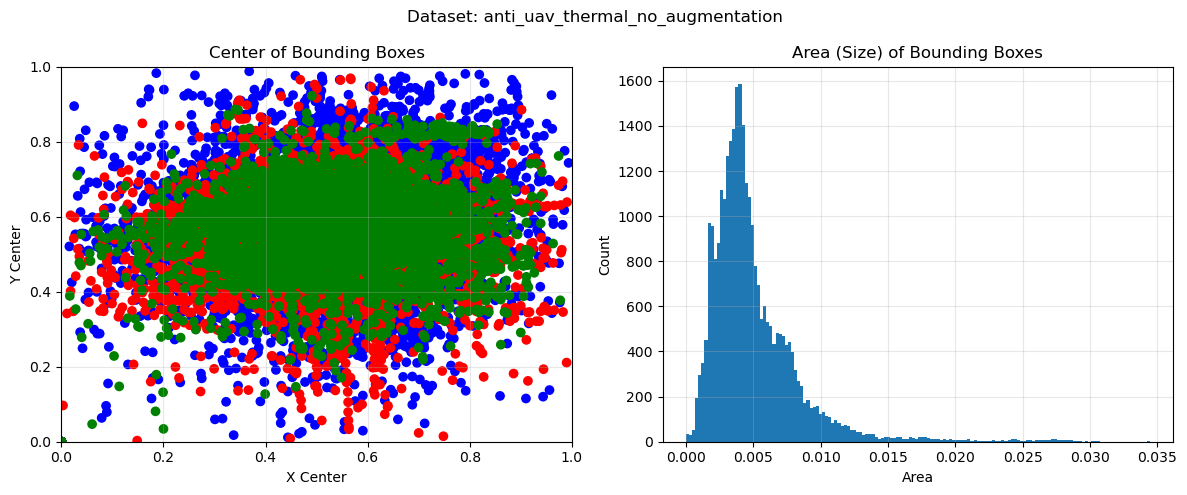

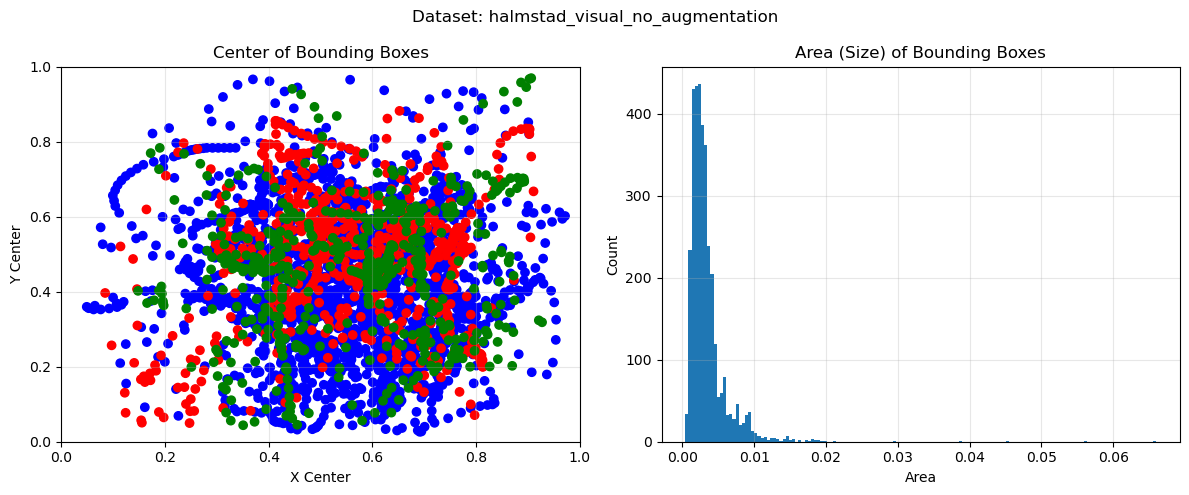

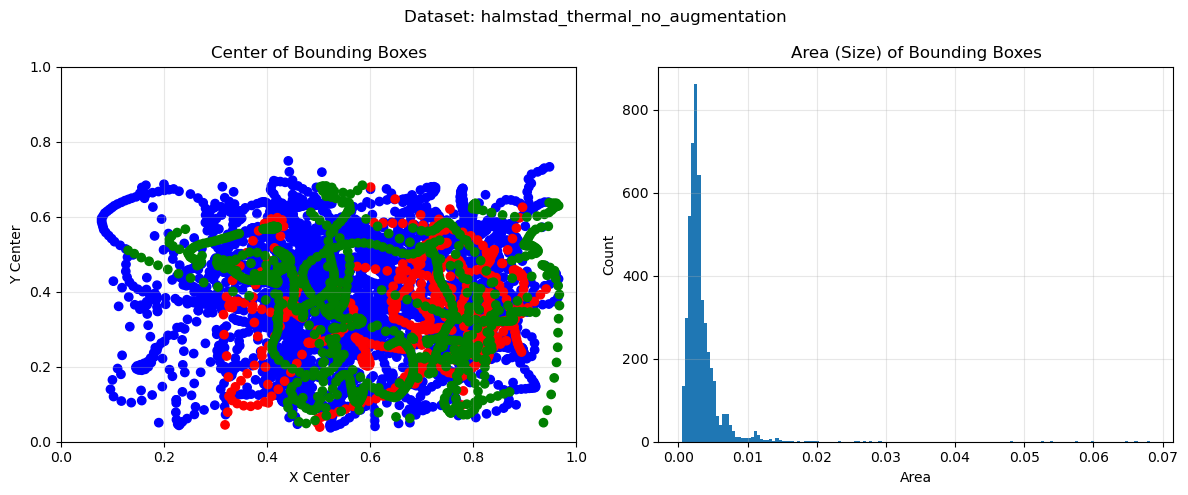

In [18]:
for dataset in dataset_names:
    # Store data from labels.
    all_x = []
    all_y = []
    all_areas = []
    subset_colors = []

    # Map colors to test set.
    colors = {"train": "blue", "valid": "green", "test": "red"}

    for subset in test_sets:
        base_dir = os.path.join("..", "datasets", dataset, subset)
        labels_dir = os.path.join(base_dir, "labels")
        label_files = os.listdir(labels_dir)

        for label_file in label_files:
            label_path = os.path.join(labels_dir, label_file)

            # Get numbers in labels.
            with open(label_path) as f:
                content = f.read().split()

                # Set numbers to be displayed in graphs based on what they represent
                # (location/size of bounding box).
                if content:
                    x = float(content[1])
                    y = float(content[2])
                    w = float(content[3])
                    h = float(content[4])

                    # Add values to the list.
                    all_x.append(x)
                    all_y.append(y)
                    all_areas.append(w * h)
                    subset_colors.append(colors[subset])

    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Dataset: {dataset}")

    # Scatter plot for the center of bounding boxes
    ax1.scatter(all_x, all_y, c=subset_colors)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel("X Center")
    ax1.set_ylabel("Y Center")
    ax1.set_title("Center of Bounding Boxes")
    ax1.grid(True, alpha=0.3)

    # Histogram of areas
    ax2.hist(all_areas, bins=150)
    ax2.set_xlabel("Area")
    ax2.set_ylabel("Count")
    ax2.set_title("Area (Size) of Bounding Boxes")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()